In [4]:
import pandas as pd
import io

nomad_data_raw = """EST	Estonia	2020	No tax on foreign-source income	$5,100 	12	€100	8	None	Moderate
BRB	Barbados	2020	No tax on remote work income (Welcome Stamp)	$4,167 	12	$2,000 	None	None	High
BMU	Bermuda	2020	0% income tax (territorial)	Not specified	12	$263 	None	None	Very High
BHS	Bahamas	2020	0% income tax (territorial)	$8,333 	12	$1,000 	None	None	High
AIA	Anguilla	2020	0% income tax (territorial)	$4,167 	12	$2,000 	None	None	Very High
ATG	Antigua and Barbuda	2020	0% income tax on foreign income	$4,167 	24	$1,500 	Long route via residency	None	Moderate
CYM	Cayman Islands	2020	0% income tax (territorial)	$8,333 	24	$1,469 	None	None	Very High
CRI	Costa Rica	2020	No tax on foreign-source income	$3,000 	12	$100 	7	None	Moderate
MUS	Mauritius	2020	No tax on foreign-source income	$1,500 	12	None	Long route via residency	None	Moderate
GEO	Georgia	2021	0% on foreign-sourced income	$2,000 	12	None	10	None	Low
HRV	Croatia	2021	1-year exemption on foreign income	$3,730 	18	€ 80	None	None	Moderate
MLT	Malta	2021	Tax-neutral if income taxed abroad	$3,965 	12	€ 300	Long route via residency	None	High
MNE	Montenegro	2021	Potential tax breaks / low tax	$1,530 	24	€ 67	10	None	Moderate
KNA	Dominica	2021	0% income tax on foreign income	$4,167 	18	$100 	None	None	Moderate
CUW	Curacao	2021	0% income tax on foreign income	$3,000 	12	$294 	None	None	High
ISL	Iceland	2021	Standard progressive tax (up to 46%)	$7,200 	6	ISK 12,200	Long route via residency	None	Very High
NOR	Norway	2021	Standard progressive tax (up to 38%)	$3,400 	24	NOK 6,300	7	Some limitations	Very High
DEU	Germany	2021	Standard progressive tax (up to 45%)	$750 	36	€ 75	5	None	High
CZE	Czech Republic	2021	Standard 15% flat tax	$2,250 	12	CZK 2,500	5	None	Moderate
PRT	Portugal	2022	20% flat on Portuguese-sourced; foreign income often exempt	$3,940 	24	€ 90	5	None	Moderate
ESP	Spain	2023	15% flat (Beckham Law) for 4 years up to €600k	$3,125 	36	€ 80	10	Some limitations	Moderate
GRC	Greece	2021	50% income tax reduction for 7 years	$3,965 	24	€ 75	7	None	Moderate
MEX	Mexico	2021	Tax resident if 183+ days; territorial otherwise	$4,300 	12	$50 	5	None	Low-Moderate
COL	Colombia	2022	Tax resident if 183+ days; territorial otherwise	$900 	24	$170 	5	None	Low
BRA	Brazil	2022	Tax resident if 183+ days; progressive up to 27.5%	$1,500 	12	$120 	4	None	Moderate
ECU	Ecuador	2022	Territorial tax system; foreign income exempt	$1,350 	24	$450 	3	None	Low
URY	Uruguay	2022	0% on tech services; territorial otherwise	Not specified	24	None	3	None	Moderate
THA	Thailand	2023	0% on foreign income if <180 days; territorial	$6,667 	120	$1,600 	None	Some limitations	Low-Moderate
ARE	UAE	2021	0% personal income tax	$5,000 	12	$611 	30	None	High
HUN	Hungary	2022	15% flat tax (lowest in EU)	$3,400 	12	€ 110	8	None	Moderate"""

columns = ["iso3", "country", "year_start", "tax", "income_req", "duration", "fee", "residency", "limitations", "barrier_level"]
df_nomad = pd.read_csv(io.StringIO(nomad_data_raw), sep="\t", names=columns)

df_nomad['cluster'] = df_nomad['barrier_level'].apply(lambda x: 'High Barriers' if 'High' in x else 'Low Barriers')

# 2. Indicator Data
df_indicators = pd.read_csv('tourism_and_macroeconomic_data.csv')
for col in ['tourism_gdp_share', 'tourism_employment', 'unemployment_rate']:
    df_indicators[col] = pd.to_numeric(df_indicators[col], errors='coerce')

# Convert year to numeric and filter
df_indicators['year'] = pd.to_numeric(df_indicators['year'], errors='coerce')
df_indicators = df_indicators.dropna(subset=['year'])

# We want "Change" - let's calculate the difference between 2019 (pre-DNV) and 2022/2023 (post-DNV)
def get_change(group, col):
    val_2019 = group[group['year'] == 2019][col].mean()
    val_latest = group[group['year'] >= 2022][col].mean()
    if pd.isna(val_2019) or pd.isna(val_latest):
        return None
    return val_latest - val_2019

changes = df_indicators.groupby('iso3').apply(lambda x: pd.Series({
    'change_tourism_gdp': get_change(x, 'tourism_gdp_share'),
    'change_tourism_employment': get_change(x, 'tourism_employment'),
    'change_unemployment': get_change(x, 'unemployment_rate')
})).reset_index()

# 3. Merge
df_final = pd.merge(df_nomad, changes, on='iso3', how='left')
df_final.to_csv('merged_nomad_indicators.csv', index=False)
print("Data prepared and saved to merged_nomad_indicators.csv")
print(df_final[['iso3', 'cluster', 'change_tourism_gdp', 'change_tourism_employment', 'change_unemployment']].head())

Data prepared and saved to merged_nomad_indicators.csv
  iso3        cluster  change_tourism_gdp  change_tourism_employment  \
0  EST   Low Barriers                 NaN                        NaN   
1  BRB  High Barriers                 NaN                  -1296.415   
2  BMU  High Barriers                 NaN                        NaN   
3  BHS  High Barriers                 NaN                        NaN   
4  AIA  High Barriers                 NaN                        NaN   

   change_unemployment  
0                  NaN  
1            -1.660333  
2                  NaN  
3                  NaN  
4                  NaN  


/tmp/ipykernel_747/1398892574.py:61: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  changes = df_indicators.groupby('iso3').apply(lambda x: pd.Series({


Visualization saved to nomad_spatial_visualization.png


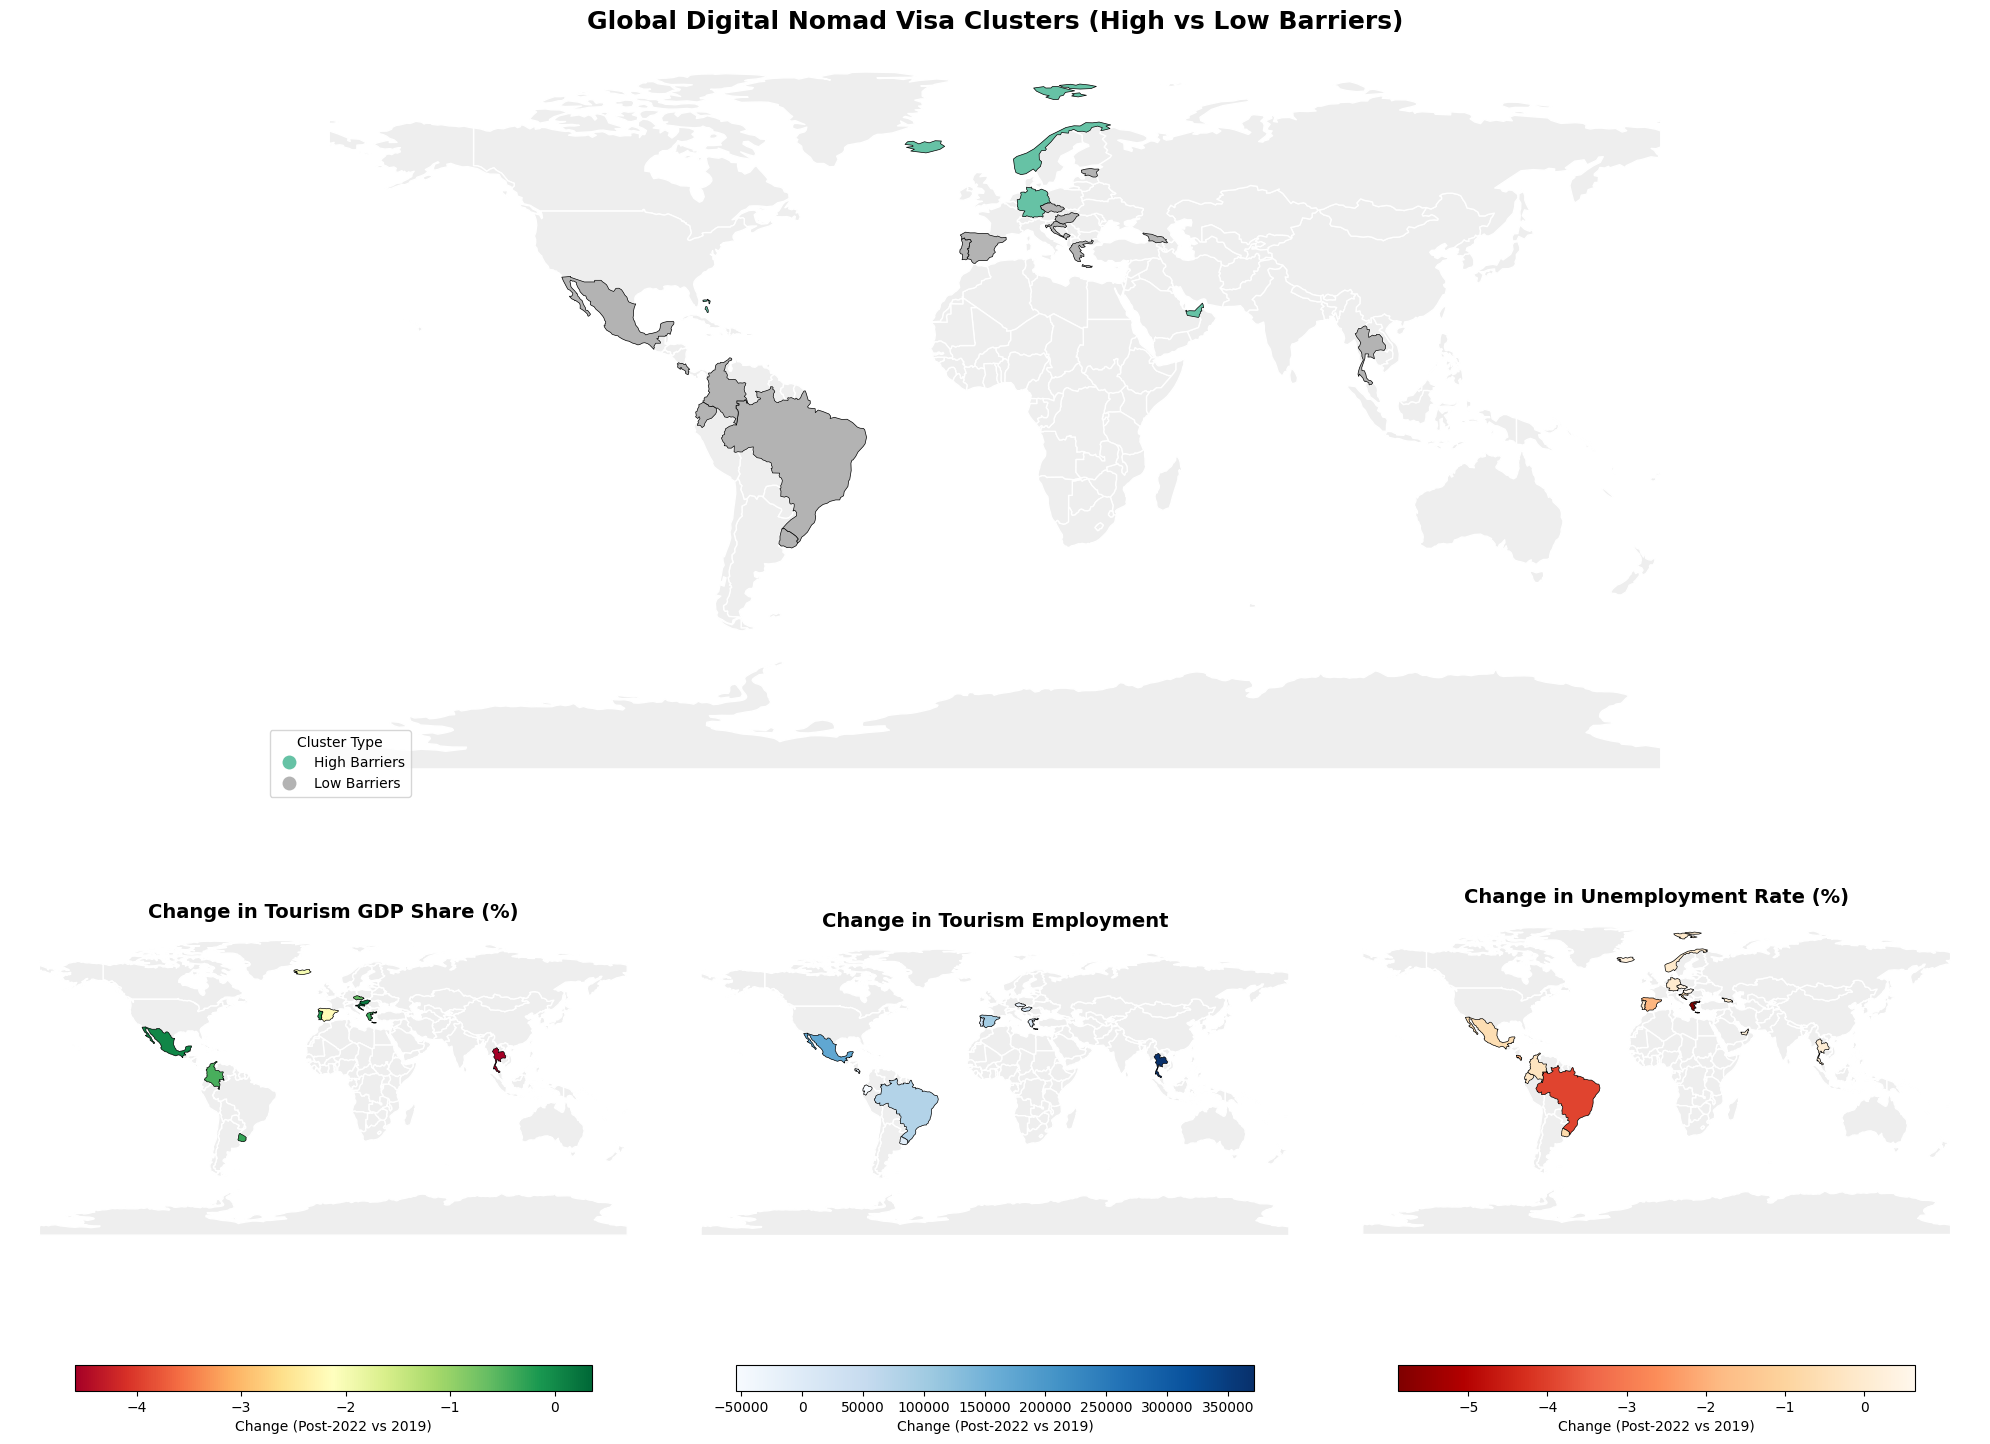

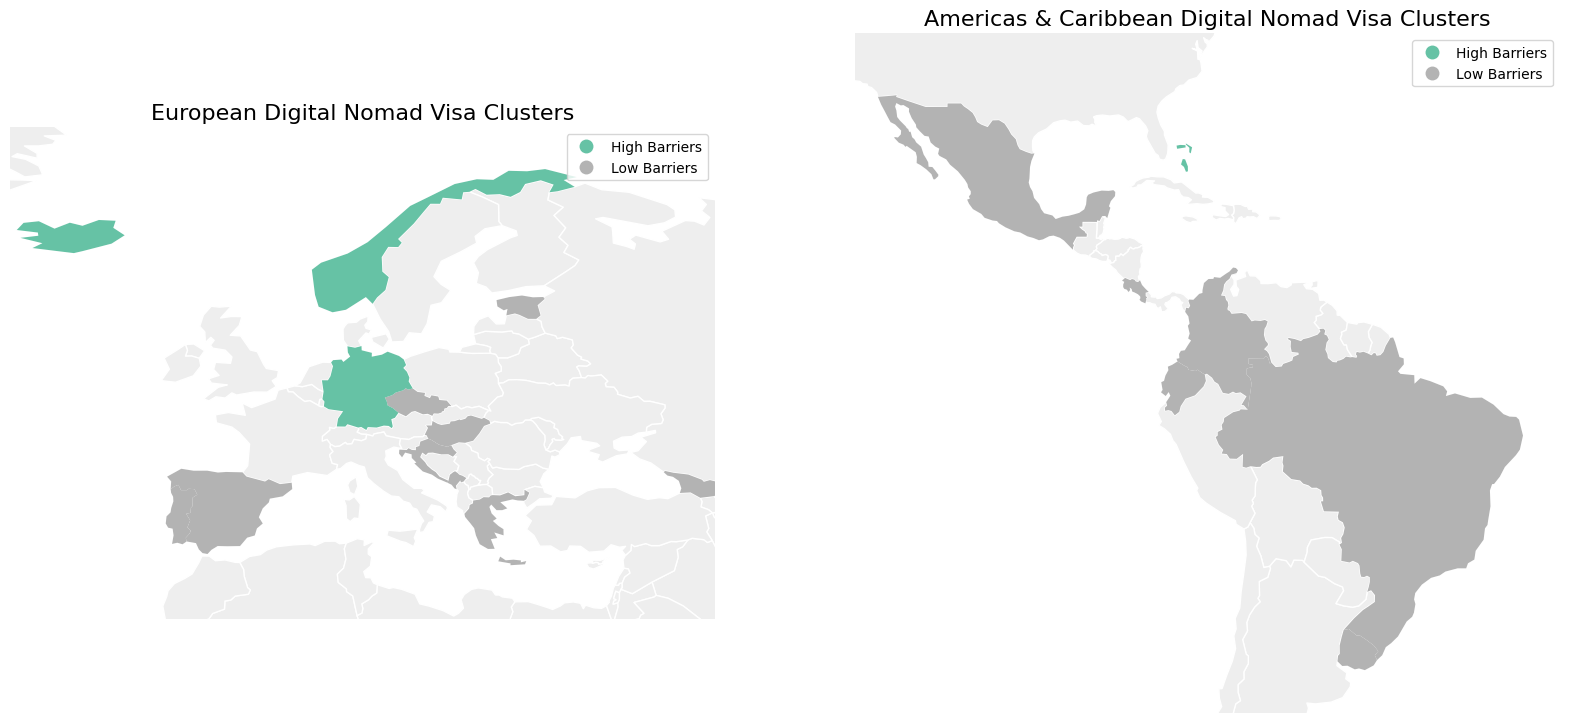

In [5]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


df = pd.read_csv('merged_nomad_indicators.csv')

# Since datasets is deprecated, using a public naturalearth URL
world_url = "https://raw.githubusercontent.com/datasets/geo-boundaries-world-110m/master/countries.geojson"
world = gpd.read_file(world_url)
if 'id' in world.columns:
    world['iso_a3'] = world['id']
elif 'ISO_A3' in world.columns:
    world['iso_a3'] = world['ISO_A3']
world_nomad = world.merge(df, left_on='iso_a3', right_on='iso3', how='left')
fig = plt.figure(figsize=(20, 15))
gs = fig.add_gridspec(2, 3)

# 1. Global Map: Cluster Type
ax_main = fig.add_subplot(gs[0, :])
world.plot(ax=ax_main, color='#EEEEEE', edgecolor='white') # Background for all countries
world_nomad.dropna(subset=['cluster']).plot(
    column='cluster',
    ax=ax_main,
    legend=True,
    categorical=True,
    cmap='Set2',
    edgecolor='black',
    linewidth=0.5,
    legend_kwds={'title': 'Cluster Type', 'loc': 'lower left'}
)
ax_main.set_title('Global Digital Nomad Visa Clusters (High vs Low Barriers)', fontsize=18, fontweight='bold')
ax_main.axis('off')

def plot_change_map(ax, column, title, cmap):
    world.plot(ax=ax, color='#EEEEEE', edgecolor='white')
    plot_data = world_nomad.dropna(subset=[column])
    if not plot_data.empty:
        plot_data.plot(
            column=column,
            ax=ax,
            legend=True,
            cmap=cmap,
            edgecolor='black',
            linewidth=0.5,
            legend_kwds={'label': 'Change (Post-2022 vs 2019)', 'orientation': 'horizontal', 'shrink': 0.8}
        )
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')

# 2. Change in Tourism GDP
ax_gdp = fig.add_subplot(gs[1, 0])
plot_change_map(ax_gdp, 'change_tourism_gdp', 'Change in Tourism GDP Share (%)', 'RdYlGn')

# 3. Change in Tourism Employment
ax_emp = fig.add_subplot(gs[1, 1])
plot_change_map(ax_emp, 'change_tourism_employment', 'Change in Tourism Employment', 'Blues')

# 4. Change in Unemployment
ax_unemp = fig.add_subplot(gs[1, 2])
plot_change_map(ax_unemp, 'change_unemployment', 'Change in Unemployment Rate (%)', 'OrRd_r') # Red is bad, so reversed
plt.tight_layout()
plt.savefig('nomad_spatial_visualization.png', dpi=300, bbox_inches='tight')
fig_zoom, axes = plt.subplots(1, 2, figsize=(20, 10))

# Europe Zoom
world_nomad.plot(ax=axes[0], color='#EEEEEE', edgecolor='white')
world_nomad.dropna(subset=['cluster']).plot(column='cluster', ax=axes[0], cmap='Set2', legend=True)
axes[0].set_xlim([-25, 45])
axes[0].set_ylim([30, 75])
axes[0].set_title('European Digital Nomad Visa Clusters', fontsize=16)
axes[0].axis('off')

# Americas/Caribbean Zoom
world_nomad.plot(ax=axes[1], color='#EEEEEE', edgecolor='white')
world_nomad.dropna(subset=['cluster']).plot(column='cluster', ax=axes[1], cmap='Set2', legend=True)
axes[1].set_xlim([-120, -30])
axes[1].set_ylim([-40, 40])
axes[1].set_title('Americas & Caribbean Digital Nomad Visa Clusters', fontsize=16)
axes[1].axis('off')

plt.savefig('nomad_clusters_zoomed.png', dpi=300, bbox_inches='tight')
print("Visualization saved to nomad_spatial_visualization.png")
